<a href="https://colab.research.google.com/github/alphonsetandeta-hub/evolution-du-biomasse-dans-la-vallee-du-fluve-senegal/blob/main/Classification_Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Importation des packages

In [1]:
# Importer les modules nécessaires
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

# Chargement des données

Les données concernent des campagnes de marketing direct (appels téléphoniques) d'une institution bancaire portugaise.

In [2]:
bankdata=pd.read_csv("bank_cleaned.csv",sep=",",index_col=0)

FileNotFoundError: [Errno 2] No such file or directory: 'bank_cleaned.csv'

In [3]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

Saving bank_cleaned.csv to bank_cleaned.csv
User uploaded file "bank_cleaned.csv" with length 3356006 bytes


In [5]:
bankdata = pd.read_csv("bank_cleaned.csv", sep=",", index_col=0)
display(bankdata.head())

,age,job,marital,education,default,balance,housing,loan,day,month,duration,campaign,pdays,previous,poutcome,response,response_binary
0,58,management,married,tertiary,no,2143,yes,no,5,may,4.35,1,-1,0,unknown,no,0
1,44,technician,single,secondary,no,29,yes,no,5,may,2.52,1,-1,0,unknown,no,0
2,33,entrepreneur,married,secondary,no,2,yes,yes,5,may,1.27,1,-1,0,unknown,no,0
5,35,management,married,tertiary,no,231,yes,no,5,may,2.32,1,-1,0,unknown,no,0
6,28,management,single,tertiary,no,447,yes,yes,5,may,3.62,1,-1,0,unknown,no,0


In [6]:
bankdata.head()

,age,job,marital,education,default,balance,housing,loan,day,month,duration,campaign,pdays,previous,poutcome,response,response_binary
0,58,management,married,tertiary,no,2143,yes,no,5,may,4.35,1,-1,0,unknown,no,0
1,44,technician,single,secondary,no,29,yes,no,5,may,2.52,1,-1,0,unknown,no,0
2,33,entrepreneur,married,secondary,no,2,yes,yes,5,may,1.27,1,-1,0,unknown,no,0
5,35,management,married,tertiary,no,231,yes,no,5,may,2.32,1,-1,0,unknown,no,0
6,28,management,single,tertiary,no,447,yes,yes,5,may,3.62,1,-1,0,unknown,no,0


## Description de la base de données "bank_cleaned.csv"

La base de données "bank_cleaned.csv" contient des données sur les campagnes de marketing direct (appels téléphoniques) d'une institution bancaire portugaise. Les données ont été nettoyées et préparées pour l'analyse.

Les caractéristiques (variables explicatives) enregistrées pour chaque client sont les suivantes :

-age : l'âge du client (variable numérique)

-job : la profession du client (variable catégorielle)

-marital : l'état matrimonial du client (variable catégorielle)

-education : le niveau d'éducation du client (variable catégorielle)

-default : indique si le client a un crédit en défaut ou non (variable catégorielle)

-balance : le solde du compte du client (variable numérique)

-housing : indique si le client a un prêt immobilier ou non (variable catégorielle)

-loan : indique si le client a un prêt personnel ou non (variable catégorielle)

-day : le jour du mois de la dernière communication avec le client (variable numérique)

-month : le mois de la dernière communication avec le client (variable catégorielle)

-duration : la durée de la dernière communication avec le client, en secondes (variable numérique)

-campaign : le nombre de contacts effectués au cours de cette campagne pour ce client (variable numérique)

-pdays : le nombre de jours écoulés depuis le dernier contact avec le client lors d'une campagne précédente (variable numérique ; 999 signifie que le client n'a pas été contacté précédemment)

-previous : le nombre de contacts effectués avant cette campagne pour ce client (variable numérique)

-poutcome : le résultat de la précédente campagne marketing (variable catégorielle)

-response : la réponse du client à la dernière campagne marketing (variable catégorielle)

-response_binary : la réponse du client à la dernière campagne marketing, encodée en binaire (0 = pas intéressé, 1 = intéressé) (variable numérique)


La variable cible est :

- response_binary : a-t-il souscrit un dépôt à terme ? (variable catégorielle)

Les données ont été préparées pour l'analyse en remplaçant les valeurs manquantes par des valeurs médianes ou moyennes, en convertissant les variables catégorielles en variables binaires, et en supprimant les variables inutiles ou redondantes.

La base de données contient 4521 entrées (lignes) et 9 caractéristiques (colonnes).




In [7]:
# Renommer les colonnes
bankdata.rename(columns={
    'age': 'age',
    'job': 'profession',
    'marital': 'situation_familiale',
    'education': 'niveau_etudes',
    'default': 'defaut_credit',
    'balance': 'solde_bancaire',
    'housing': 'pret_immobilier',
    'loan': 'pret_personnel',
    'day': 'jour_du_mois',
    'month': 'mois',
    'duration': 'duree_appel',
    'campaign': 'nb_appels',
    'pdays': 'nb_jours_depuis_dernier_appel',
    'previous': 'nb_appels_precedents',
    'poutcome': 'resultat_campagne_precedente',
    'response': 'reponse_campagne_actuelle',
    'response_binary': 'reponse_campagne_actuelle_binaire'
}, inplace=True)

# Afficher les noms de colonnes mis à jour
print(bankdata.columns)

Index(['age', 'profession', 'situation_familiale', 'niveau_etudes',
       'defaut_credit', 'solde_bancaire', 'pret_immobilier', 'pret_personnel',
       'jour_du_mois', 'mois', 'duree_appel', 'nb_appels',
       'nb_jours_depuis_dernier_appel', 'nb_appels_precedents',
       'resultat_campagne_precedente', 'reponse_campagne_actuelle',
       'reponse_campagne_actuelle_binaire'],
      dtype='object')


## Qualité des données

In [8]:
bankdata.info()

<class 'pandas.core.frame.DataFrame'>
Index: 40841 entries, 0 to 45209
Data columns (total 17 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   age                                40841 non-null  int64  
 1   profession                         40841 non-null  object 
 2   situation_familiale                40841 non-null  object 
 3   niveau_etudes                      40841 non-null  object 
 4   defaut_credit                      40841 non-null  object 
 5   solde_bancaire                     40841 non-null  int64  
 6   pret_immobilier                    40841 non-null  object 
 7   pret_personnel                     40841 non-null  object 
 8   jour_du_mois                       40841 non-null  int64  
 9   mois                               40841 non-null  object 
 10  duree_appel                        40841 non-null  float64
 11  nb_appels                          40841 non-null  int64  


In [9]:
bankdata.describe(include="all")

,age,profession,situation_familiale,niveau_etudes,defaut_credit,solde_bancaire,pret_immobilier,pret_personnel,jour_du_mois,mois,duree_appel,nb_appels,nb_jours_depuis_dernier_appel,nb_appels_precedents,resultat_campagne_precedente,reponse_campagne_actuelle,reponse_campagne_actuelle_binaire
count,40841.000000,40841,40841,40841,40841,40841.000000,40841,40841,40841.000000,40841,40841.000000,40841.000000,40841.000000,40841.000000,40841,40841,40841.000000
unique,NaN,12,3,3,2,NaN,2,2,NaN,12,NaN,NaN,NaN,NaN,3,2,NaN
top,NaN,blue-collar,married,secondary,no,NaN,yes,no,NaN,may,NaN,NaN,NaN,NaN,unknown,no,NaN
freq,NaN,8805,24641,21933,40078,NaN,22820,34042,NaN,12496,NaN,NaN,NaN,NaN,34802,36202,NaN
mean,40.790676,NaN,NaN,NaN,NaN,1073.981807,NaN,NaN,15.863666,NaN,4.308949,2.774149,32.248304,0.436791,NaN,NaN,0.113587
std,10.475473,NaN,NaN,NaN,NaN,1712.556186,NaN,NaN,8.313608,NaN,4.305823,3.104177,90.738402,1.572342,NaN,NaN,0.317313
min,18.000000,NaN,NaN,NaN,NaN,-6847.000000,NaN,NaN,1.000000,NaN,0.100000,1.000000,-1.000000,0.000000,NaN,NaN,0.000000
25%,33.000000,NaN,NaN,NaN,NaN,64.000000,NaN,NaN,8.000000,NaN,1.730000,1.000000,-1.000000,0.000000,NaN,NaN,0.000000
50%,39.000000,NaN,NaN,NaN,NaN,421.000000,NaN,NaN,16.000000,NaN,3.000000,2.000000,-1.000000,0.000000,NaN,NaN,0.000000
75%,48.000000,NaN,NaN,NaN,NaN,1333.000000,NaN,NaN,21.000000,NaN,5.300000,3.000000,-1.000000,0.000000,NaN,NaN,0.000000


In [ ]:
bankdata.isnull().sum()

age                                  0
profession                           0
situation_familiale                  0
niveau_etudes                        0
defaut_credit                        0
solde_bancaire                       0
pret_immobilier                      0
pret_personnel                       0
jour_du_mois                         0
mois                                 0
duree_appel                          0
nb_appels                            0
nb_jours_depuis_dernier_appel        0
nb_appels_precedents                 0
resultat_campagne_precedente         0
reponse_campagne_actuelle            0
reponse_campagne_actuelle_binaire    0
dtype: int64

# Descripition de la base de données

In [10]:
# Créer une nouvelle version de la base de données sans la variable "response"
bankdata_new = bankdata.drop(columns=['reponse_campagne_actuelle_binaire'])
bankdata_new.head()

,age,profession,situation_familiale,niveau_etudes,defaut_credit,solde_bancaire,pret_immobilier,pret_personnel,jour_du_mois,mois,duree_appel,nb_appels,nb_jours_depuis_dernier_appel,nb_appels_precedents,resultat_campagne_precedente,reponse_campagne_actuelle
0,58,management,married,tertiary,no,2143,yes,no,5,may,4.35,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,5,may,2.52,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,5,may,1.27,1,-1,0,unknown,no
5,35,management,married,tertiary,no,231,yes,no,5,may,2.32,1,-1,0,unknown,no
6,28,management,single,tertiary,no,447,yes,yes,5,may,3.62,1,-1,0,unknown,no


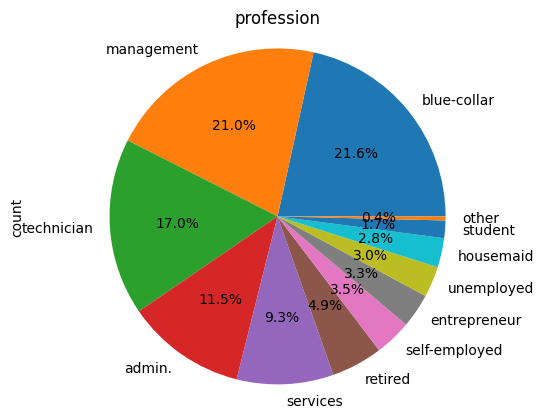

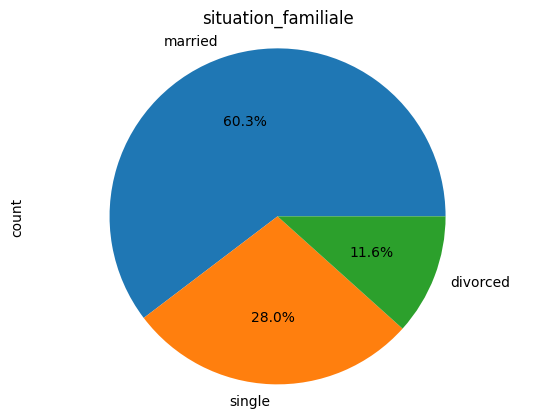

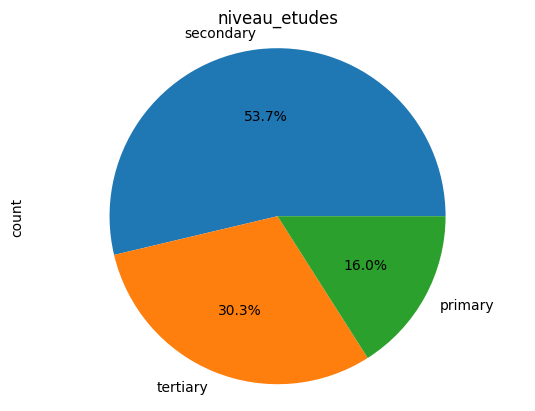

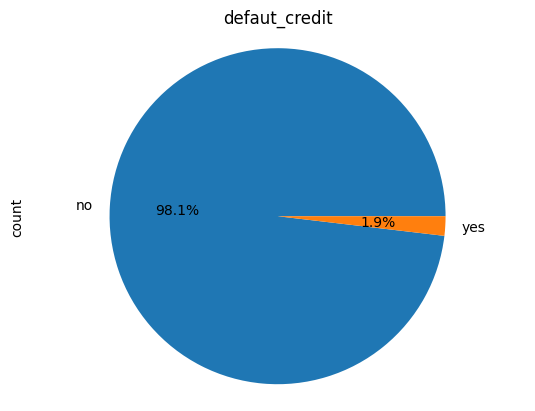

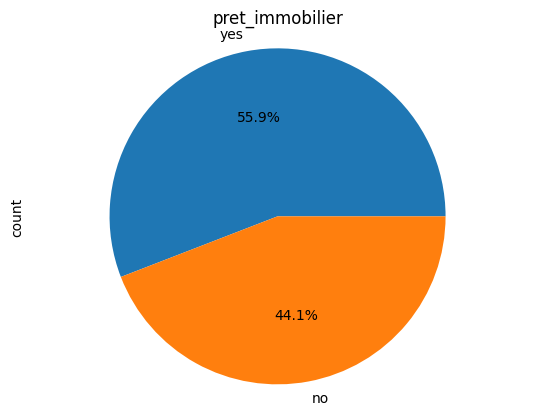

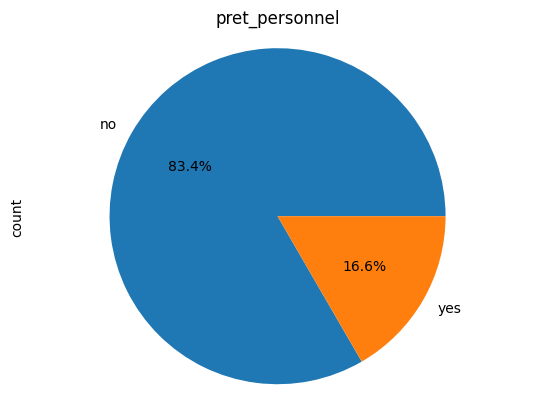

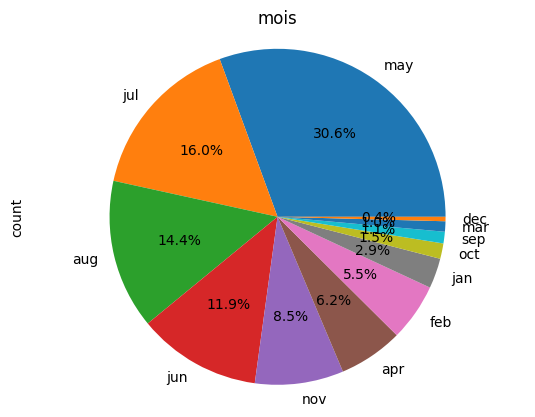

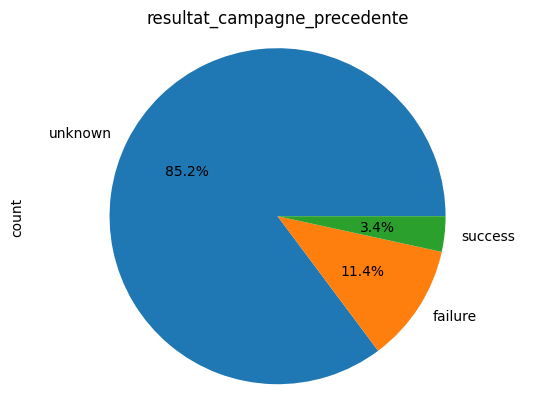

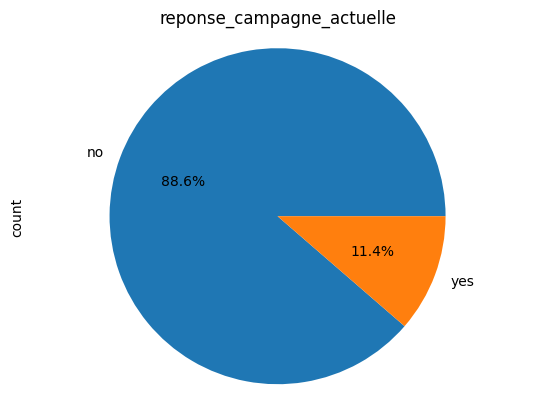

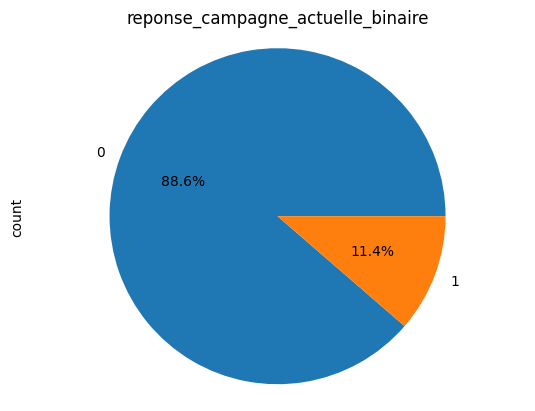

In [11]:


# Sélectionner les variables catégorielles
cat_vars = ['profession', 'situation_familiale', 'niveau_etudes', 'defaut_credit', 'pret_immobilier', 'pret_personnel',
             'mois', 'resultat_campagne_precedente', 'reponse_campagne_actuelle', 'reponse_campagne_actuelle_binaire']


# Générer un pie plot pour chaque variable catégorielle
for var in cat_vars:
    bankdata[var].value_counts().plot(kind='pie', autopct='%1.1f%%')
    plt.title(var)
    plt.axis('equal')
    plt.show()


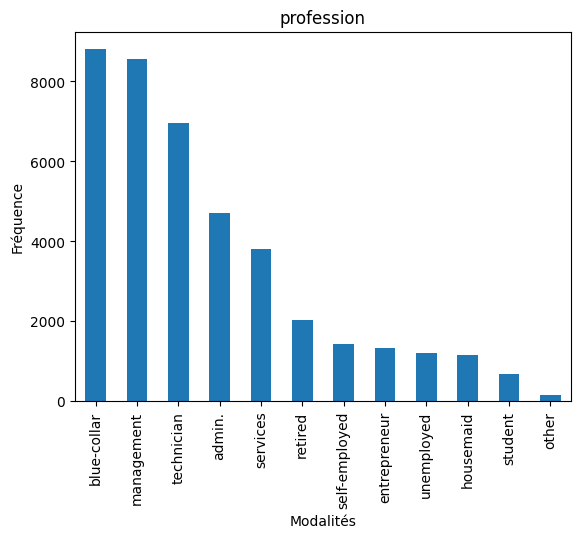

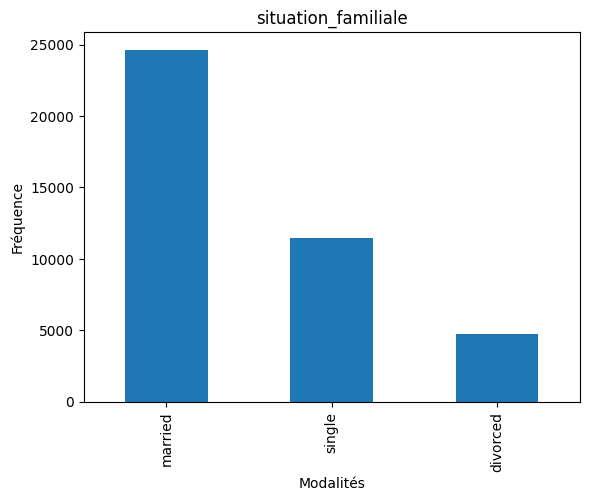

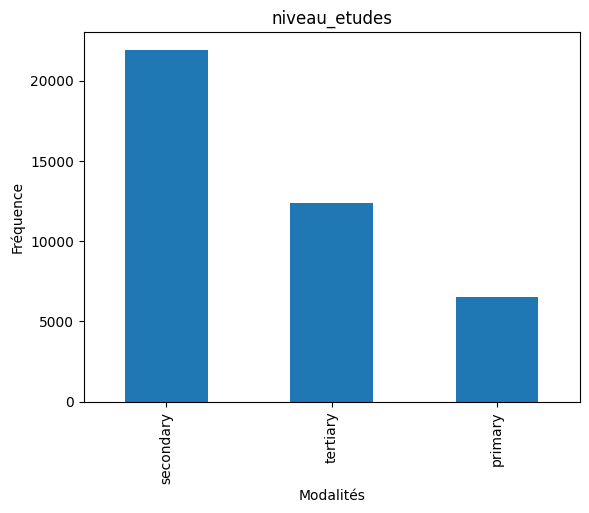

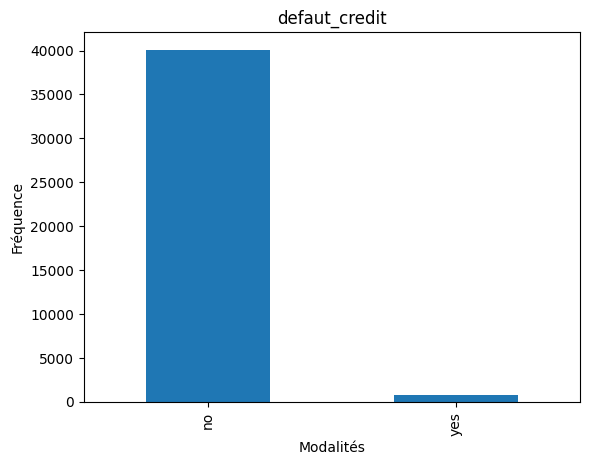

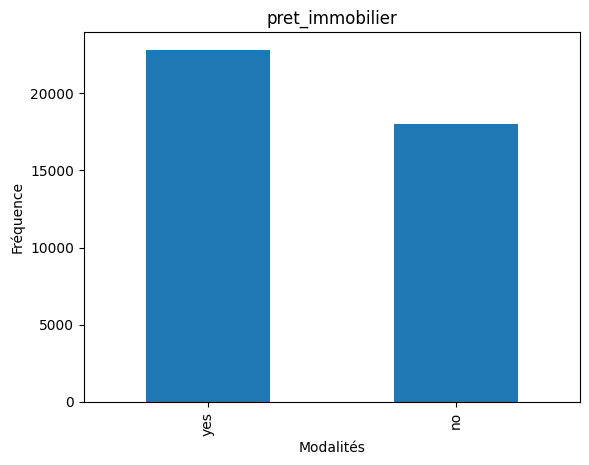

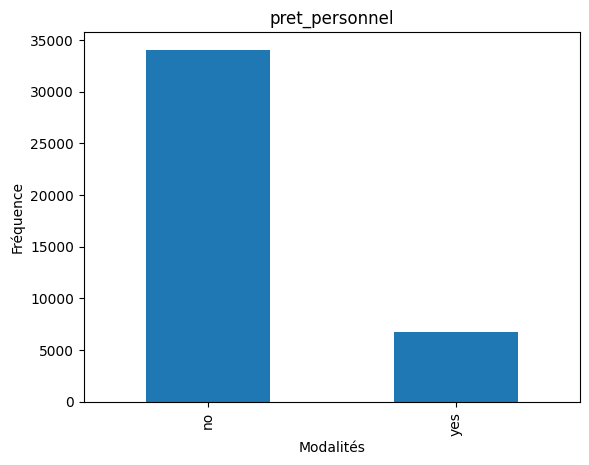

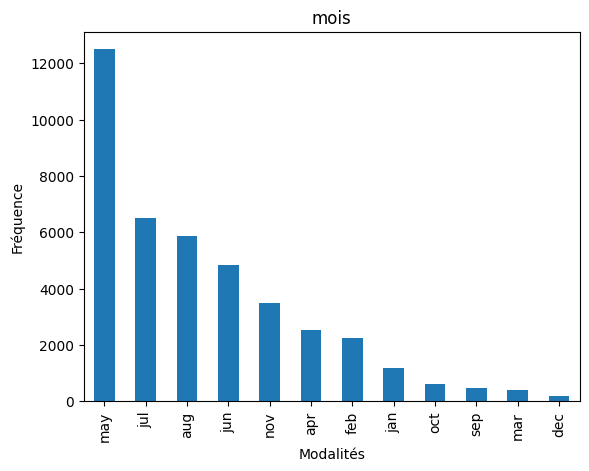

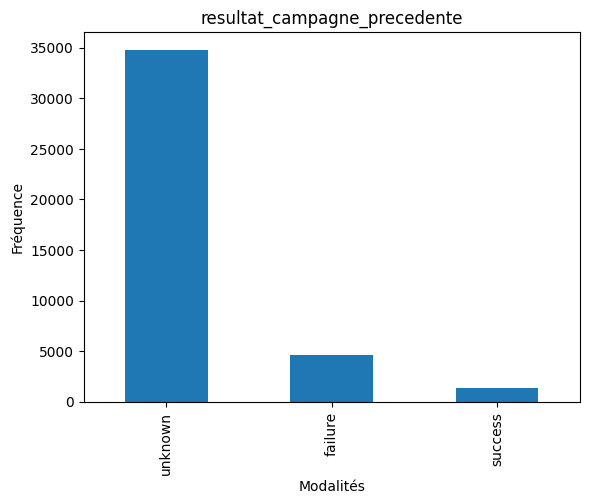

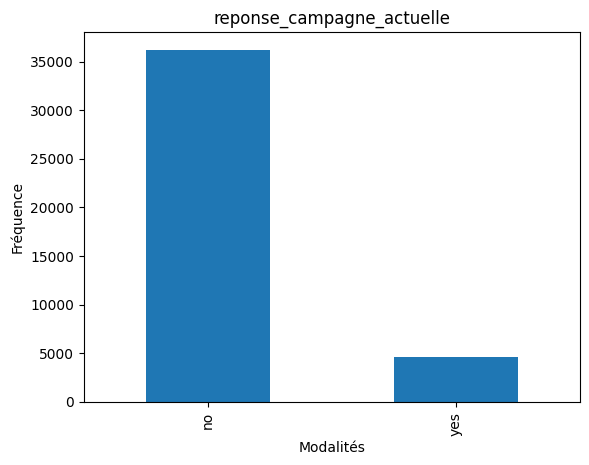

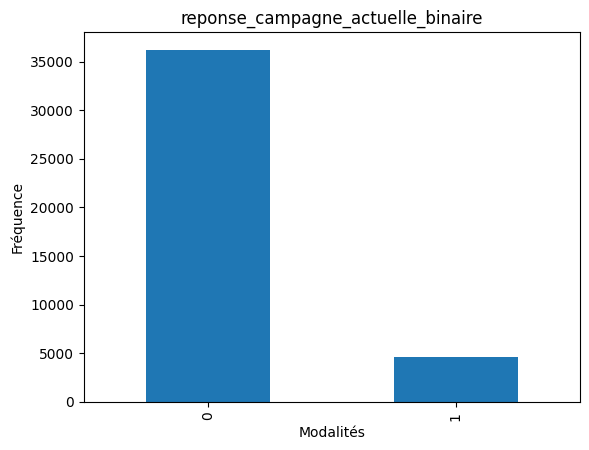

In [12]:

# Générer un bar plot pour chaque variable catégorielle
for var in cat_vars:
    bankdata[var].value_counts().plot(kind='bar')
    plt.title(var)
    plt.xlabel('Modalités')
    plt.ylabel('Fréquence')
    plt.show()

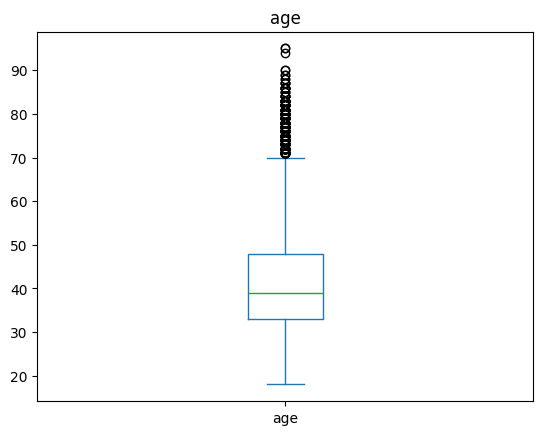

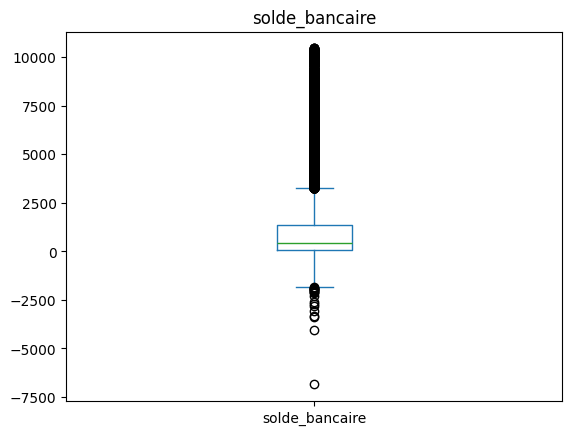

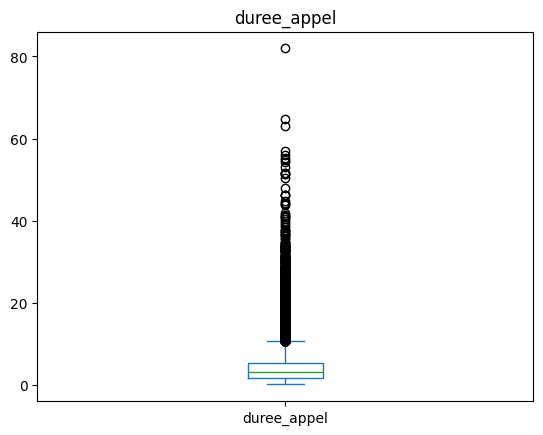

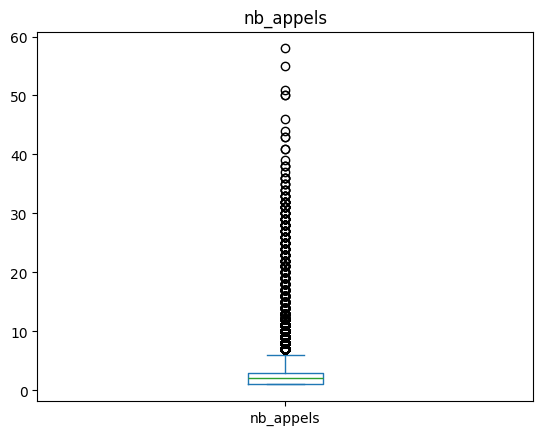

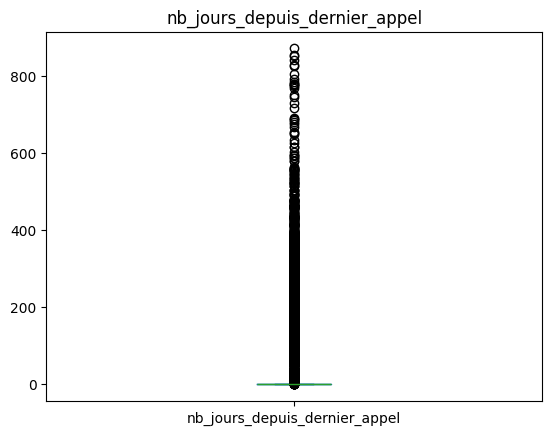

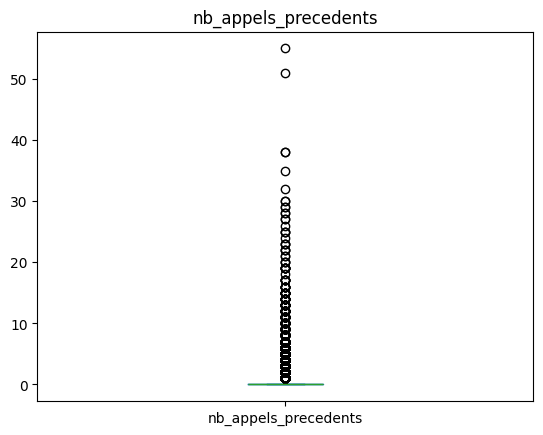

In [13]:


# Sélectionner les variables numériques
num_vars = ['age', 'solde_bancaire', 'duree_appel', 'nb_appels', 'nb_jours_depuis_dernier_appel', 'nb_appels_precedents']

# Générer un box plot pour chaque variable numérique
for var in num_vars:
    bankdata[var].plot(kind='box')
    plt.title(var)
    plt.show()

# Analyses bivariée

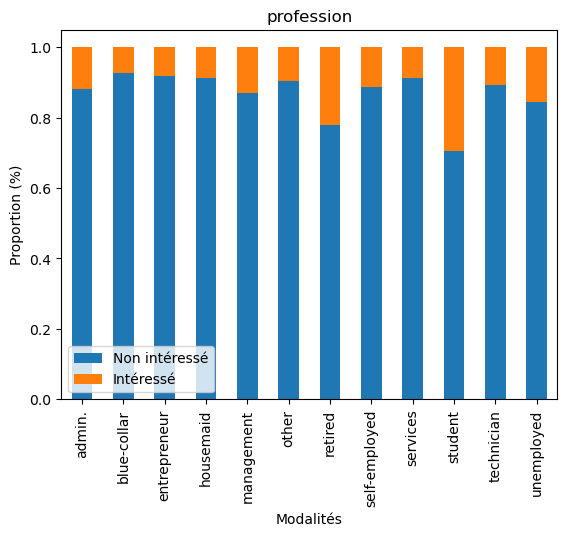

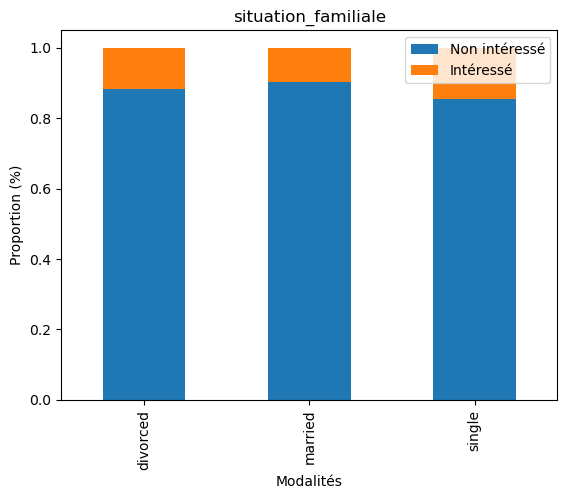

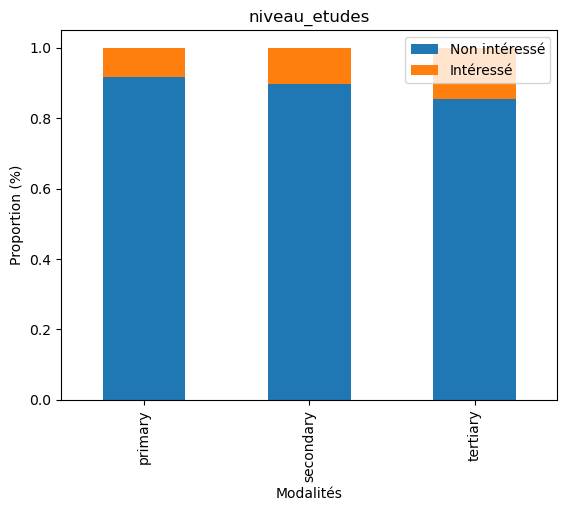

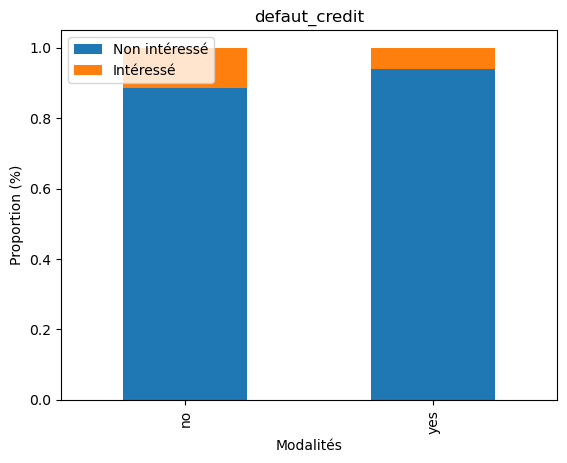

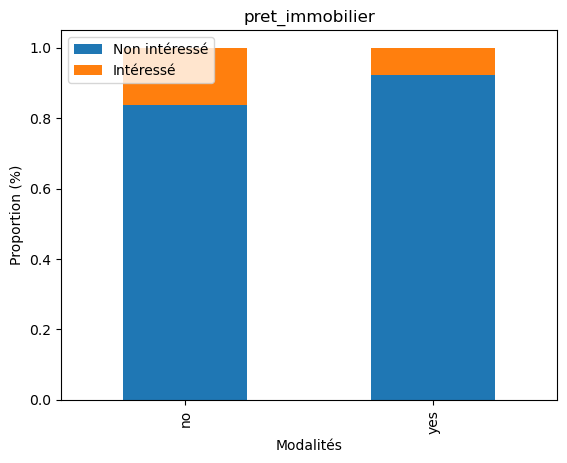

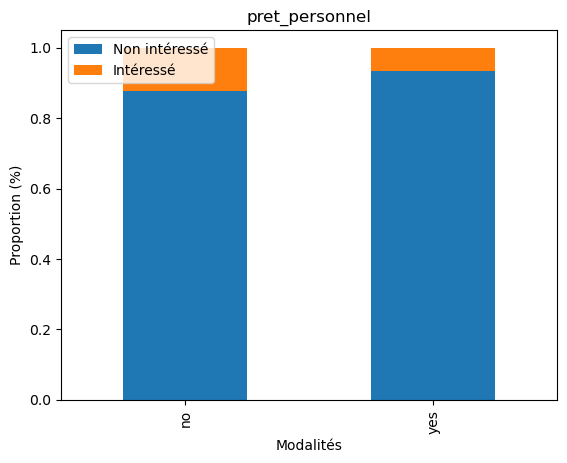

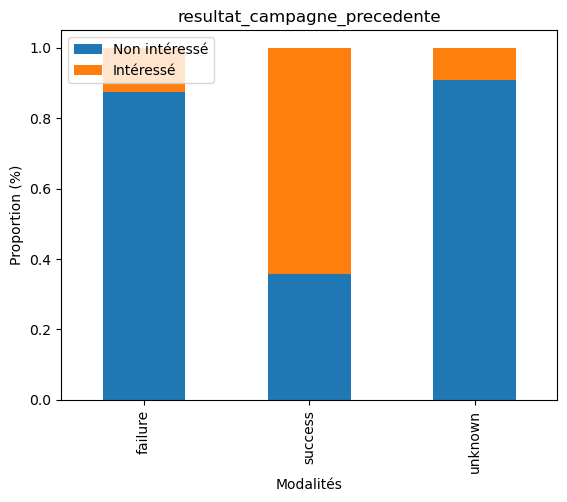

In [ ]:
import seaborn as sns
# Sélectionner les variables catégorielles
# Sélectionner les variables catégorielles
cat_vars = ['profession', 'situation_familiale', 'niveau_etudes', 'defaut_credit', 'pret_immobilier', 'pret_personnel', 'resultat_campagne_precedente']


# Générer un count plot pour chaque variable catégorielle
# Définir la taille des figures




# Générer un bar plot pour chaque variable catégorielle
for var in cat_vars:
    figsize = (20, 20)
    (bankdata.groupby([var, 'reponse_campagne_actuelle_binaire'])['reponse_campagne_actuelle_binaire'].count()/bankdata.groupby([var])[var].count()).unstack(level=1).plot(kind='bar', stacked=True)
    plt.title(var)
    plt.xlabel('Modalités')
    plt.ylabel('Proportion (%)')
    plt.legend(['Non intéressé', 'Intéressé'])
    plt.show()

In [14]:

from scipy.stats import chi2_contingency
# Sélectionner les variables catégorielles
cat_vars = ['profession', 'situation_familiale', 'niveau_etudes', 'defaut_credit', 'pret_immobilier', 'pret_personnel', 'resultat_campagne_precedente']

# Initialiser les listes pour stocker les résultats
var_names = []
chi2_stats = []
p_values = []
cramer_vs = []

# Parcourir toutes les variables catégorielles
for var in cat_vars:
    # Calculer le tableau de contingence
    contingency_table = pd.crosstab(bankdata['reponse_campagne_actuelle_binaire'], bankdata[var])
    # Calculer la statistique de test du Chi-deux et la p-valeur
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    # Calculer le coefficient V de Cramer
    n = contingency_table.sum().sum()
    phi2 = chi2/n
    r,k = contingency_table.shape
    phi2corr = max(0, phi2-((k-1)*(r-1))/(n-1))
    rc = r-((r-1)**2)/(n-1)
    kc = k-((k-1)**2)/(n-1)
    cramer_v = np.sqrt(phi2corr/min(rc-1,kc-1))
    # Ajouter les résultats aux listes correspondantes
    var_names.append(var)
    chi2_stats.append(chi2)
    p_values.append(p)
    cramer_vs.append(cramer_v)

# Créer un DataFrame avec les résultats
results_df = pd.DataFrame({
    'Variable': var_names,
    'Chi2': chi2_stats,
    'P-valeur': p_values,
    'V de Cramer': cramer_vs
})

# Trier le DataFrame par ordre croissant de V de Cramer
results_df.sort_values(by='V de Cramer', inplace=True,ascending=False)

# Afficher le tableau des résultats
print(results_df)

                       Variable         Chi2       P-valeur  V de Cramer
6  resultat_campagne_precedente  4072.108164   0.000000e+00     0.315689
4               pret_immobilier   720.301364  1.151140e-158     0.132713
0                    profession   708.668621  7.474840e-145     0.130702
2                 niveau_etudes   210.723005   1.746147e-46     0.071489
1           situation_familiale   181.858771   3.234965e-40     0.066363
5                pret_personnel   176.976953   2.215667e-40     0.065642
3                 defaut_credit    21.401052   3.725668e-06     0.022350


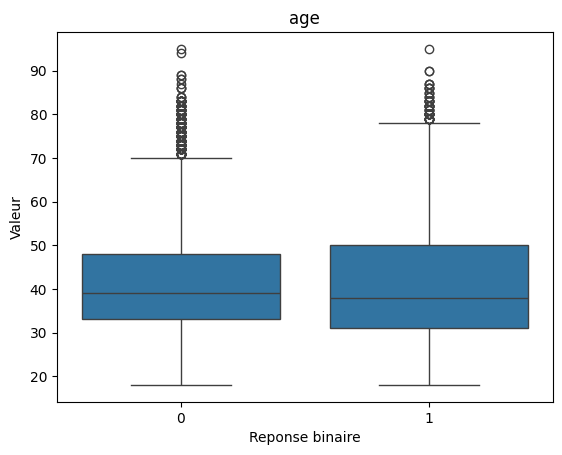

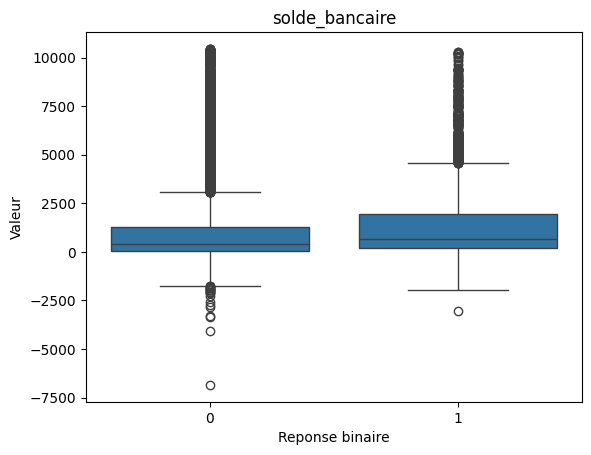

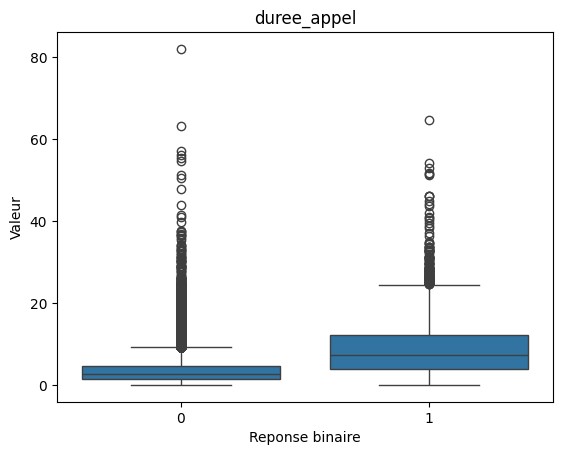

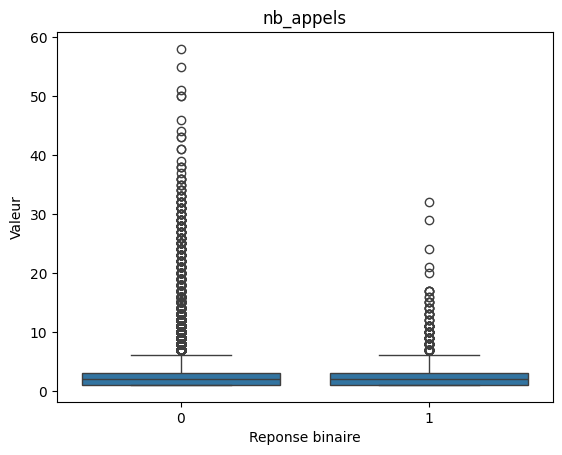

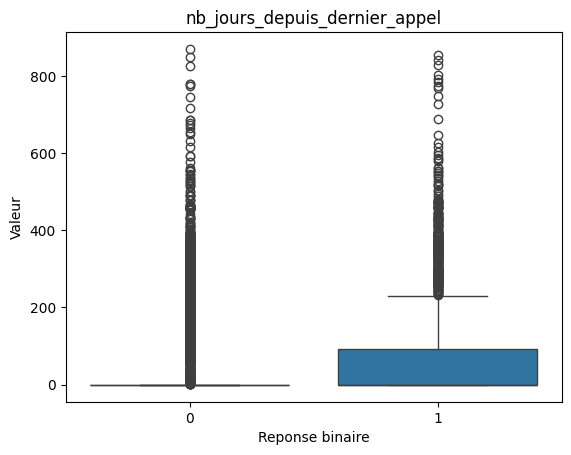

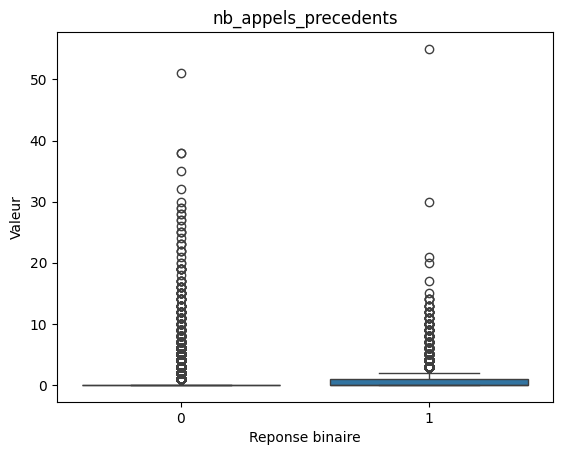

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# Sélectionner les variables numériques

# Sélectionner les variables numériques
num_vars = ['age', 'solde_bancaire', 'duree_appel', 'nb_appels', 'nb_jours_depuis_dernier_appel', 'nb_appels_precedents']


# Générer un box plot pour chaque variable numérique
for var in num_vars:
    sns.boxplot(x='reponse_campagne_actuelle_binaire', y=var, data=bankdata)
    plt.title(var)
    plt.xlabel('Reponse binaire')
    plt.ylabel('Valeur')
    plt.show()

In [17]:
import scipy.stats as stats
# Initialiser les listes pour stocker les résultats
var_names = []
kw_stats = []
p_values = []

# Parcourir toutes les variables numériques
for var in num_vars:
    # Calculer les groupes de valeurs
    groups = [bankdata[bankdata['reponse_campagne_actuelle_binaire'] == 0][var], bankdata[bankdata['reponse_campagne_actuelle_binaire'] == 1][var]]
    # Appliquer le test de Kruskal-Wallis
    kw_stat, p = stats.kruskal(*groups)
    # Ajouter les résultats aux listes correspondantes
    var_names.append(var)
    kw_stats.append(kw_stat)
    p_values.append(p)

# Créer un DataFrame avec les résultats
results_df = pd.DataFrame({
    'Variable': var_names,
    'Kruskal-Wallis': kw_stats,
    'P-valeur': p_values
})

# Trier le DataFrame par ordre croissant de p-valeur
results_df.sort_values(by='P-valeur', inplace=True)

# Afficher le tableau des résultats
print(results_df)

                        Variable  Kruskal-Wallis       P-valeur
2                    duree_appel     4767.047442   0.000000e+00
5           nb_appels_precedents     1241.504630  5.825212e-272
4  nb_jours_depuis_dernier_appel     1060.285642  1.414875e-232
1                 solde_bancaire      367.404987   6.874073e-82
3                      nb_appels      290.919176   3.135286e-65
0                            age        4.517712   3.354567e-02


# Modélisation

In [18]:
import statsmodels.api as sm
# Sélectionner les variables explicatives et la variable d'intérêt
X = bankdata[['age', 'profession', 'situation_familiale', 'niveau_etudes', 'defaut_credit', 'solde_bancaire',
              'pret_immobilier', 'pret_personnel', 'duree_appel', 'nb_appels', 'nb_jours_depuis_dernier_appel',
              'nb_appels_precedents', 'resultat_campagne_precedente']]
y = bankdata['reponse_campagne_actuelle_binaire']

In [19]:
# Convertir les variables catégorielles en variables indicatrices (dummies)
X = pd.get_dummies(X, columns=['profession', 'situation_familiale', 'niveau_etudes', 'defaut_credit', 'pret_immobilier',
                               'pret_personnel',  'resultat_campagne_precedente'], drop_first=True)


In [20]:
# Ajouter une constante pour l'interception
X = sm.add_constant(X)

In [21]:
# Diviser les données en ensembles d'apprentissage et de test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [23]:
# Créer le modèle de régression logistique
# Convertir X_train en float pour s'assurer que toutes les colonnes sont numériques
X_train = X_train.astype(float)
logit_model = sm.Logit(y_train, X_train)

In [24]:
# Ajuster le modèle aux données d'apprentissage
result = logit_model.fit()


Optimization terminated successfully.
         Current function value: 0.245375
         Iterations 8


In [25]:
# Afficher le résumé des résultats de la régression
print(result.summary())

                                   Logit Regression Results                                  
Dep. Variable:     reponse_campagne_actuelle_binaire   No. Observations:                32672
Model:                                         Logit   Df Residuals:                    32645
Method:                                          MLE   Df Model:                           26
Date:                               Mon, 20 Apr 2026   Pseudo R-squ.:                  0.2973
Time:                                       17:57:48   Log-Likelihood:                -8016.9
converged:                                      True   LL-Null:                       -11409.
Covariance Type:                           nonrobust   LLR p-value:                     0.000
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
const                                 

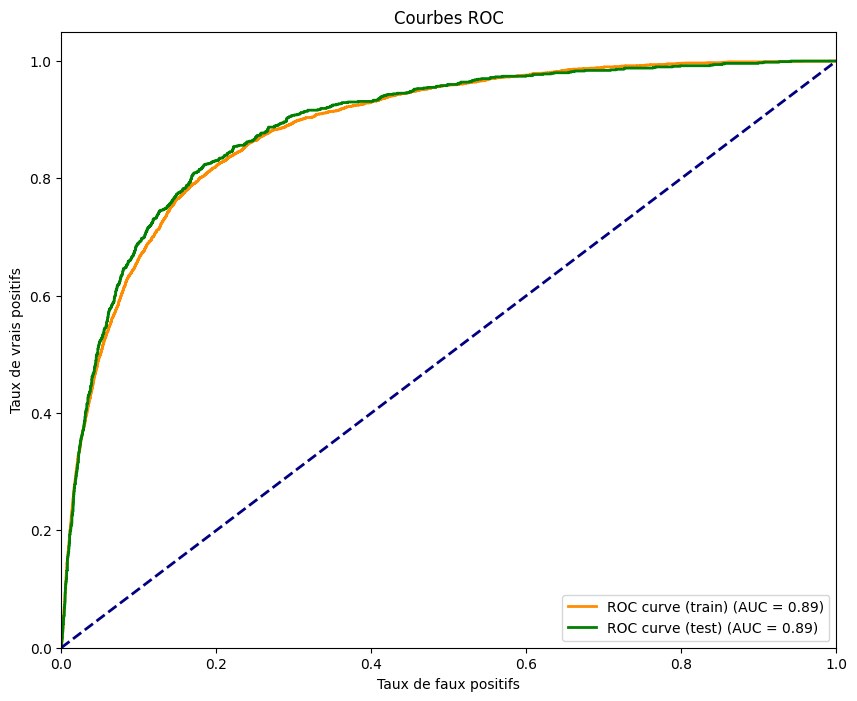

In [27]:
from sklearn.metrics import roc_curve, auc
# Obtenir les prédictions du modèle sur l'ensemble d'entraînement et de test
y_train_pred = result.predict(X_train)
# Convertir X_test en float pour assurer la cohérence avec X_train
X_test = X_test.astype(float)
y_test_pred = result.predict(X_test)

# Calculer les courbes ROC et les aires sous la courbe (AUC)
fpr_train, tpr_train, thresholds_train = roc_curve(y_train, y_train_pred)
roc_auc_train = auc(fpr_train, tpr_train)

fpr_test, tpr_test, thresholds_test = roc_curve(y_test, y_test_pred)
roc_auc_test = auc(fpr_test, tpr_test)

# Tracer les courbes ROC
plt.figure(figsize=(10, 8))
plt.plot(fpr_train, tpr_train, color='darkorange', lw=2, label='ROC curve (train) (AUC = %0.2f)' % roc_auc_train)
plt.plot(fpr_test, tpr_test, color='green', lw=2, label='ROC curve (test) (AUC = %0.2f)' % roc_auc_test)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de faux positifs')
plt.ylabel('Taux de vrais positifs')
plt.title('Courbes ROC')
plt.legend(loc="lower right")
plt.show()

In [28]:
from sklearn.metrics import classification_report

# Prédire les classes sur la base de test
y_pred = result.predict(X_test) > 0.5

# Générer le rapport de classification
report = classification_report(y_test, y_pred)

# Afficher le rapport de classification
print(report)

              precision    recall  f1-score   support

           0       0.91      0.98      0.94      7166
           1       0.67      0.32      0.43      1003

    accuracy                           0.90      8169
   macro avg       0.79      0.65      0.69      8169
weighted avg       0.88      0.90      0.88      8169



In [29]:
from sklearn.metrics import confusion_matrix
confusion_matrix = confusion_matrix(y_test, y_pred)
print(confusion_matrix)

[[7013  153]
 [ 686  317]]


In [30]:
from sklearn.metrics import classification_report

# Prédire les classes sur la base de test
y_pred = result.predict(X_train) > 0.5

# Générer le rapport de classification
report = classification_report(y_train, y_pred)

# Afficher le rapport de classification
print(report)

              precision    recall  f1-score   support

           0       0.92      0.98      0.95     29036
           1       0.66      0.32      0.43      3636

    accuracy                           0.91     32672
   macro avg       0.79      0.65      0.69     32672
weighted avg       0.89      0.91      0.89     32672



In [31]:
from sklearn.metrics import confusion_matrix
confusion_matrix = confusion_matrix(y_train, y_pred)
print(confusion_matrix)

[[28425   611]
 [ 2473  1163]]


In [32]:
2*0.89-1

0.78

In [33]:
import tensorflow as tf
from tensorflow import keras
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Define the neural network model
model = keras.Sequential([
    keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(1, activation='sigmoid')  # Output layer for binary classification
])

# Compile the model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Train the model
print("Training the neural network...")
history = model.fit(X_train, y_train, epochs=20, batch_size=32, validation_split=0.2, verbose=1)

# Evaluate the model on the test set
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"\nNeural Network Test Accuracy: {accuracy:.4f}")

# Make predictions and evaluate further
y_pred_proba_nn = model.predict(X_test)
y_pred_nn = (y_pred_proba_nn > 0.5).astype(int)

print("\nClassification Report (Neural Network):")
print(classification_report(y_test, y_pred_nn))

print("\nConfusion Matrix (Neural Network):")
print(confusion_matrix(y_test, y_pred_nn))

roc_auc_nn = roc_auc_score(y_test, y_pred_proba_nn)
print(f"\nROC AUC Score (Neural Network): {roc_auc_nn:.4f}")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training the neural network...
Epoch 1/20
817/817 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.8235 - loss: 5.0875 - val_accuracy: 0.8912 - val_loss: 0.4537
Epoch 2/20
817/817 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8827 - loss: 0.5108 - val_accuracy: 0.8912 - val_loss: 0.3695
Epoch 3/20
817/817 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8864 - loss: 0.3891 - val_accuracy: 0.8912 - val_loss: 0.3458
Epoch 4/20
817/817 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8872 - loss: 0.3613 - val_accuracy: 0.8912 - val_loss: 0.3371
Epoch 5/20
817/817 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8877 - loss: 0.3508 - val_accuracy: 0.8912 - val_loss: 0.3343
Epoch 6/20
817/817 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8879 - loss: 0.3431 - val_accuracy: 0.8912 - val_loss: 0.3334
Epoch 7/20
817/817 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8879 - loss: 0.3421 - val_accuracy: 0.8912 - val_loss: 0.3309
Epoch 8/20
817/817 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.8878 - 

In [36]:
print("\nNeural Network Model Summary:")
model.summary()


Neural Network Model Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,717 (45.77 KB)

 Trainable params: 3,905 (15.25 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 7,812 (30.52 KB)

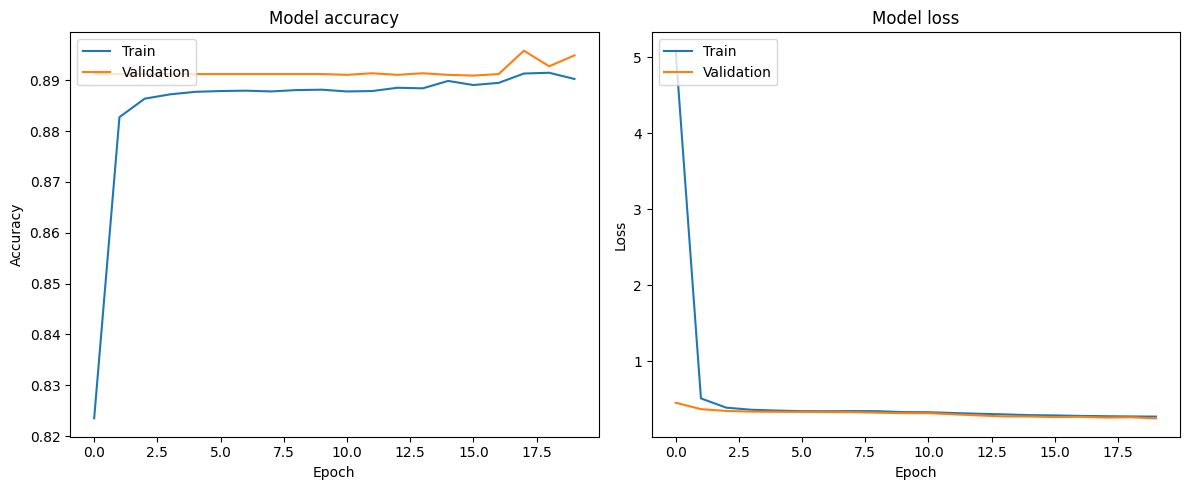

In [34]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.tight_layout()
plt.show()

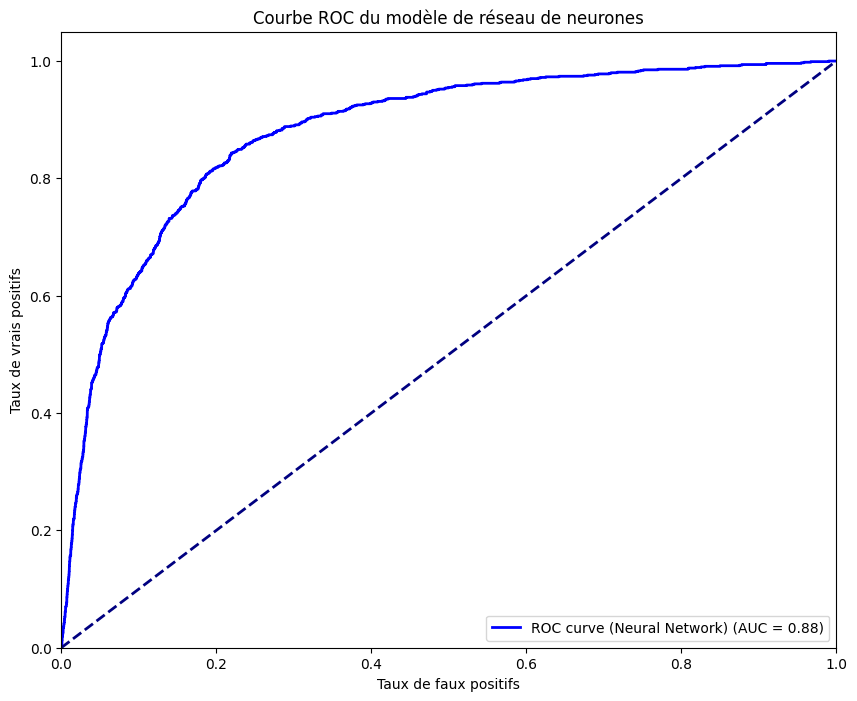

In [35]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Calculate ROC curve for the neural network
fpr_nn, tpr_nn, thresholds_nn = roc_curve(y_test, y_pred_proba_nn)

# Plot ROC curve
plt.figure(figsize=(10, 8))
plt.plot(fpr_nn, tpr_nn, color='blue', lw=2, label='ROC curve (Neural Network) (AUC = %0.2f)' % roc_auc_nn)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Taux de faux positifs')
plt.ylabel('Taux de vrais positifs')
plt.title('Courbe ROC du modèle de réseau de neurones')
plt.legend(loc="lower right")
plt.show()

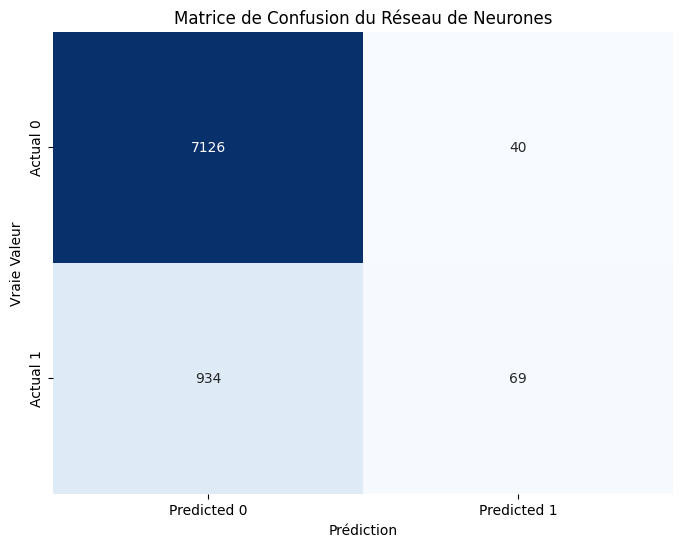

In [37]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Compute the confusion matrix for the neural network predictions
cm_nn = confusion_matrix(y_test, y_pred_nn)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_nn, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Matrice de Confusion du Réseau de Neurones')
plt.xlabel('Prédiction')
plt.ylabel('Vraie Valeur')
plt.show()

## Modélisation avec Random Forest

In [38]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and train the Random Forest Classifier
print("Training Random Forest Classifier...")
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_rf = rf_model.predict(X_test)
y_pred_proba_rf = rf_model.predict_proba(X_test)[:, 1]

# Evaluate the Random Forest model
print("\nClassification Report (Random Forest):")
print(classification_report(y_test, y_pred_rf))

print("\nConfusion Matrix (Random Forest):")
print(confusion_matrix(y_test, y_pred_rf))

roc_auc_rf = roc_auc_score(y_test, y_pred_proba_rf)
print(f"\nROC AUC Score (Random Forest): {roc_auc_rf:.4f}")

Training Random Forest Classifier...

Classification Report (Random Forest):
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      7166
           1       0.66      0.37      0.47      1003

    accuracy                           0.90      8169
   macro avg       0.79      0.67      0.71      8169
weighted avg       0.89      0.90      0.89      8169


Confusion Matrix (Random Forest):
[[6980  186]
 [ 635  368]]

ROC AUC Score (Random Forest): 0.8912


## Modélisation avec XGBoost

### Pistes pour réduire les faux négatifs du modèle XGBoost

Les faux négatifs (le modèle prédit 0 alors que la vraie valeur est 1) sont souvent critiques dans les problèmes de classification où le coût d'une erreur de type II est élevé (par exemple, manquer un client intéressé par un dépôt bancaire). Voici quelques pistes pour les réduire :

1.  **Ajuster le seuil de classification :**
    *   Par défaut, un seuil de 0.5 est utilisé pour convertir les probabilités prédites en classes binaires (si probabilité > 0.5, alors 1, sinon 0). Pour réduire les faux négatifs, on peut abaisser ce seuil (par exemple, à 0.3 ou 0.4). Cela rendra le modèle plus sensible à la classe positive, classifiant plus d'instances comme 1, mais cela pourrait augmenter le nombre de faux positifs.

2.  **Gérer le déséquilibre des classes :**
    *   Le jeu de données semble présenter un déséquilibre de classes (environ 11% de réponses positives). Les modèles ont tendance à être moins performants sur la classe minoritaire. Des techniques peuvent être utilisées pour y remédier :
        *   **Oversampling de la classe minoritaire :** Dupliquer des instances de la classe minoritaire ou générer des échantillons synthétiques (par exemple, avec SMOTE - Synthetic Minority Oversampling Technique).
        *   **Undersampling de la classe majoritaire :** Réduire le nombre d'instances de la classe majoritaire. Cela peut entraîner une perte d'informations.
        *   **Pondération des classes :** Attribuer un poids plus élevé à la classe minoritaire lors de l'entraînement du modèle. XGBoost a un paramètre `scale_pos_weight` pour cela.

3.  **Ingénierie de fonctionnalités (Feature Engineering) :**
    *   Créer de nouvelles fonctionnalités ou transformer celles existantes pourrait aider le modèle à mieux distinguer les classes. Par exemple, combiner certaines variables ou créer des indicateurs basés sur le comportement passé.

4.  **Optimisation des hyperparamètres axée sur le rappel :**
    *   Lors de l'optimisation des hyperparamètres, privilégiez des métriques qui valorisent le rappel (comme le score F1 ou le rappel directement) au lieu de l'AUC si la réduction des faux négatifs est l'objectif principal.

Commençons par explorer l'ajustement du seuil de classification, car c'est une méthode rapide à tester et souvent efficace pour réduire les faux négatifs.

In [44]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# Re-évaluer le modèle XGBoost optimisé avec un seuil de classification ajusté

# Définir un nouveau seuil (par exemple, 0.3)
new_threshold = 0.3

y_pred_proba_xgb_tuned = best_xgb_model.predict_proba(X_test)[:, 1]
y_pred_xgb_tuned_adjusted = (y_pred_proba_xgb_tuned > new_threshold).astype(int)

print(f"\nClassification Report (Tuned XGBoost avec seuil ajusté à {new_threshold}):")
print(classification_report(y_test, y_pred_xgb_tuned_adjusted))

print(f"\nConfusion Matrix (Tuned XGBoost avec seuil ajusté à {new_threshold}):")
print(confusion_matrix(y_test, y_pred_xgb_tuned_adjusted))

roc_auc_xgb_tuned_adjusted = roc_auc_score(y_test, y_pred_proba_xgb_tuned)
print(f"\nROC AUC Score (Tuned XGBoost avec seuil ajusté à {new_threshold}): {roc_auc_xgb_tuned_adjusted:.4f}")


Classification Report (Tuned XGBoost avec seuil ajusté à 0.3):
              precision    recall  f1-score   support

           0       0.95      0.94      0.94      7166
           1       0.59      0.61      0.60      1003

    accuracy                           0.90      8169
   macro avg       0.77      0.78      0.77      8169
weighted avg       0.90      0.90      0.90      8169


Confusion Matrix (Tuned XGBoost avec seuil ajusté à 0.3):
[[6733  433]
 [ 390  613]]

ROC AUC Score (Tuned XGBoost avec seuil ajusté à 0.3): 0.9100


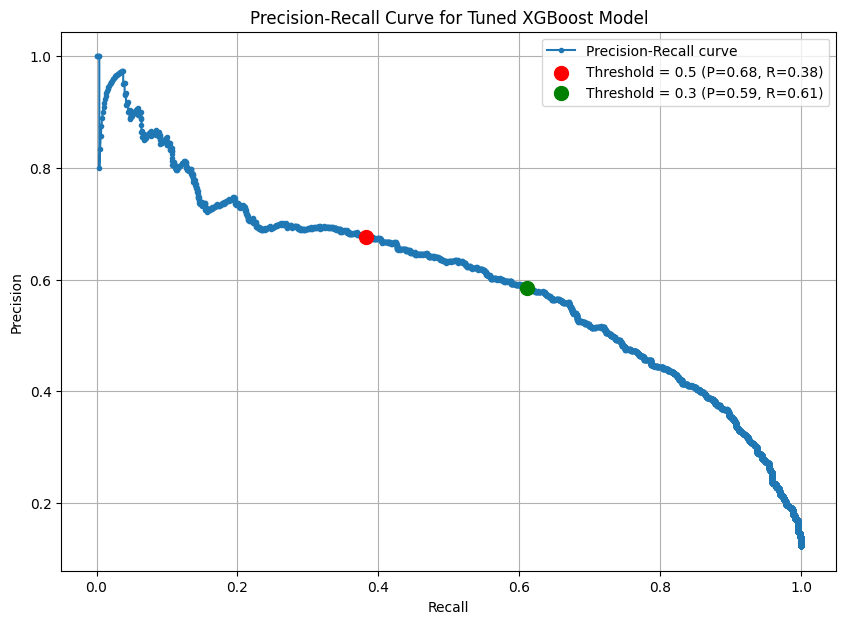

In [45]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# Get predicted probabilities for the tuned XGBoost model on the test set
y_pred_proba_xgb = best_xgb_model.predict_proba(X_test)[:, 1]

# Calculate precision-recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba_xgb)

# Find the index for the default threshold (0.5)
default_threshold = 0.5
idx_default = np.argmin(np.abs(thresholds - default_threshold))

# Find the index for the adjusted threshold (0.3)
adjusted_threshold = 0.3
idx_adjusted = np.argmin(np.abs(thresholds - adjusted_threshold))

plt.figure(figsize=(10, 7))
plt.plot(recall, precision, marker='.', label='Precision-Recall curve')
plt.scatter(recall[idx_default], precision[idx_default], marker='o', color='red',
            label=f'Threshold = {default_threshold:.1f} (P={precision[idx_default]:.2f}, R={recall[idx_default]:.2f})',
            s=100, zorder=5)
plt.scatter(recall[idx_adjusted], precision[idx_adjusted], marker='o', color='green',
            label=f'Threshold = {adjusted_threshold:.1f} (P={precision[idx_adjusted]:.2f}, R={recall[idx_adjusted]:.2f})',
            s=100, zorder=5)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for Tuned XGBoost Model')
plt.legend()
plt.grid(True)
plt.show()

## Optimisation des Hyperparamètres XGBoost avec RandomizedSearchCV

In [40]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform, randint

# Define the parameter space for RandomizedSearchCV
param_dist = {
    'n_estimators': randint(100, 500),  # Number of boosting rounds
    'learning_rate': uniform(0.01, 0.3), # Step size shrinkage
    'max_depth': randint(3, 10),      # Maximum depth of a tree
    'subsample': uniform(0.6, 0.4),   # Subsample ratio of the training instance
    'colsample_bytree': uniform(0.6, 0.4), # Subsample ratio of columns when constructing each tree
    'gamma': uniform(0, 0.5),         # Minimum loss reduction required to make a further partition
    'lambda': uniform(1, 2),          # L2 regularization term
    'alpha': uniform(0, 1),           # L1 regularization term
}

# Initialize XGBClassifier for hyperparameter tuning
# Ensure use_label_encoder=False and eval_metric='logloss' for compatibility
# and suppress the warning as it's common practice now.
xgb_tuning_model = xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss', use_label_encoder=False, random_state=42, n_jobs=-1)

# Initialize RandomizedSearchCV
# n_iter: number of parameter settings that are sampled. More is better but takes longer.
# cv: number of cross-validation folds
print("Performing RandomizedSearchCV for XGBoost...")
random_search = RandomizedSearchCV(
    estimator=xgb_tuning_model,
    param_distributions=param_dist,
    n_iter=50,  # You can increase this for a more thorough search
    scoring='roc_auc', # Optimize for ROC AUC score
    cv=3,       # 3-fold cross-validation
    verbose=1,  # Output progress
    random_state=42,
    n_jobs=-1   # Use all available cores
)

# Fit RandomizedSearchCV to the training data
random_search.fit(X_train, y_train)

print("\nBest hyperparameters found:", random_search.best_params_)
print("Best ROC AUC score on training data (cross-validated):", random_search.best_score_)

# Get the best model
best_xgb_model = random_search.best_estimator_

# Make predictions with the best model on the test set
y_pred_xgb_tuned = best_xgb_model.predict(X_test)
y_pred_proba_xgb_tuned = best_xgb_model.predict_proba(X_test)[:, 1]

# Evaluate the tuned XGBoost model
print("\nClassification Report (Tuned XGBoost):")
print(classification_report(y_test, y_pred_xgb_tuned))

print("\nConfusion Matrix (Tuned XGBoost):")
print(confusion_matrix(y_test, y_pred_xgb_tuned))

roc_auc_xgb_tuned = roc_auc_score(y_test, y_pred_proba_xgb_tuned)
print(f"\nROC AUC Score (Tuned XGBoost): {roc_auc_xgb_tuned:.4f}")

Performing RandomizedSearchCV for XGBoost...
Fitting 3 folds for each of 50 candidates, totalling 150 fits


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:11:21] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Best hyperparameters found: {'alpha': np.float64(0.009197051616629648), 'colsample_bytree': np.float64(0.6405886171464128), 'gamma': np.float64(0.3317508845540279), 'lambda': np.float64(1.0101231676924374), 'learning_rate': np.float64(0.0582424154252496), 'max_depth': 4, 'n_estimators': 293, 'subsample': np.float64(0.8767580790770773)}
Best ROC AUC score on training data (cross-validated): 0.9001678104262361

Classification Report (Tuned XGBoost):
              precision    recall  f1-score   support

           0       0.92      0.97      0.95      7166
           1       0.68      0.38      0.49      1003

    accuracy                           0.90      8169
   macro avg       0.80      0.68      0.72      8169
weighted avg       0.89      0.90      0.89      8169


Confusion Matrix (Tuned XGBoost):
[[6983  183]
 [ 619  384]]

ROC AUC Score (Tuned XGBoost): 0.9100


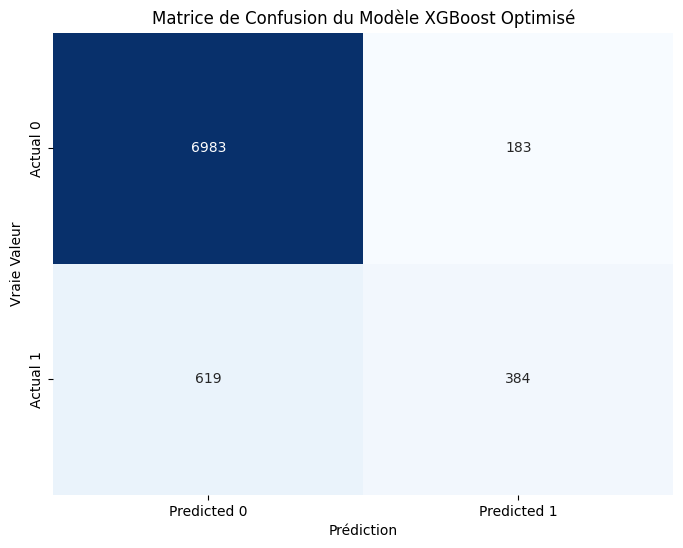

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Compute the confusion matrix for the tuned XGBoost predictions
cm_xgb_tuned = confusion_matrix(y_test, y_pred_xgb_tuned)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_xgb_tuned, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Predicted 0', 'Predicted 1'],
            yticklabels=['Actual 0', 'Actual 1'])
plt.title('Matrice de Confusion du Modèle XGBoost Optimisé')
plt.xlabel('Prédiction')
plt.ylabel('Vraie Valeur')
plt.show()

### Analyse des erreurs du modèle XGBoost Optimisé

Pour mieux comprendre où le modèle XGBoost optimisé fait des erreurs, nous allons afficher quelques-uns des cas mal classés. Cela nous permettra d'examiner les caractéristiques de ces observations et potentiellement d'identifier des schémas ou des problèmes spécifiques.

In [43]:
# Créer un DataFrame pour les prédictions et les vraies valeurs du jeu de test
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred_xgb_tuned
})

# Ajouter les caractéristiques originales pour une meilleure interprétation
# S'assurer que les index correspondent
results = pd.concat([results, X_test.drop(columns=['const'])], axis=1)

# Identifier les cas mal classés (où Actual != Predicted)
misclassified_samples = results[results['Actual'] != results['Predicted']]

print(f"Nombre total de cas mal classés: {len(misclassified_samples)}")

# Afficher les 10 premiers cas mal classés
print("\nLes 10 premiers cas mal classés:")
display(misclassified_samples.head(10))

# Afficher quelques cas pour lesquels le modèle a prédit 1 mais la vraie valeur est 0 (False Positives)
false_positives = misclassified_samples[(misclassified_samples['Actual'] == 0) & (misclassified_samples['Predicted'] == 1)]
print(f"\nNombre de faux positifs: {len(false_positives)}")
print("\nLes 5 premiers faux positifs:")
display(false_positives.head(5))

# Afficher quelques cas pour lesquels le modèle a prédit 0 mais la vraie valeur est 1 (False Negatives)
false_negatives = misclassified_samples[(misclassified_samples['Actual'] == 1) & (misclassified_samples['Predicted'] == 0)]
print(f"\nNombre de faux négatifs: {len(false_negatives)}")
print("\nLes 5 premiers faux négatifs:")
display(false_negatives.head(5))

Nombre total de cas mal classés: 802

Les 10 premiers cas mal classés:


,Actual,Predicted,age,solde_bancaire,duree_appel,nb_appels,nb_jours_depuis_dernier_appel,nb_appels_precedents,profession_blue-collar,profession_entrepreneur,...,profession_unemployed,situation_familiale_married,situation_familiale_single,niveau_etudes_secondary,niveau_etudes_tertiary,defaut_credit_yes,pret_immobilier_yes,pret_personnel_yes,resultat_campagne_precedente_success,resultat_campagne_precedente_unknown
19221,1,0,46.0,660.0,12.33,2.0,-1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
25457,1,0,37.0,156.0,6.10,3.0,-1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
14932,1,0,40.0,-839.0,16.97,2.0,-1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0
16595,1,0,51.0,603.0,14.22,2.0,-1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
22813,1,0,50.0,1396.0,12.18,6.0,-1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
41283,1,0,63.0,91.0,2.13,3.0,-1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
24373,0,1,57.0,3760.0,17.83,1.0,-1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
32281,1,0,31.0,183.0,8.25,1.0,-1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
13298,1,0,26.0,102.0,10.97,2.0,-1.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0
42086,1,0,60.0,3401.0,4.90,1.0,270.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0



Nombre de faux positifs: 183

Les 5 premiers faux positifs:


,Actual,Predicted,age,solde_bancaire,duree_appel,nb_appels,nb_jours_depuis_dernier_appel,nb_appels_precedents,profession_blue-collar,profession_entrepreneur,...,profession_unemployed,situation_familiale_married,situation_familiale_single,niveau_etudes_secondary,niveau_etudes_tertiary,defaut_credit_yes,pret_immobilier_yes,pret_personnel_yes,resultat_campagne_precedente_success,resultat_campagne_precedente_unknown
24373,0,1,57.0,3760.0,17.83,1.0,-1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
43212,0,1,63.0,367.0,4.37,1.0,178.0,6.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
41694,0,1,57.0,415.0,6.80,1.0,410.0,2.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
9449,0,1,37.0,685.0,16.13,1.0,-1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0
41003,0,1,35.0,1368.0,2.65,2.0,78.0,3.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0



Nombre de faux négatifs: 619

Les 5 premiers faux négatifs:


,Actual,Predicted,age,solde_bancaire,duree_appel,nb_appels,nb_jours_depuis_dernier_appel,nb_appels_precedents,profession_blue-collar,profession_entrepreneur,...,profession_unemployed,situation_familiale_married,situation_familiale_single,niveau_etudes_secondary,niveau_etudes_tertiary,defaut_credit_yes,pret_immobilier_yes,pret_personnel_yes,resultat_campagne_precedente_success,resultat_campagne_precedente_unknown
19221,1,0,46.0,660.0,12.33,2.0,-1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
25457,1,0,37.0,156.0,6.10,3.0,-1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
14932,1,0,40.0,-839.0,16.97,2.0,-1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0
16595,1,0,51.0,603.0,14.22,2.0,-1.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
22813,1,0,50.0,1396.0,12.18,6.0,-1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


## Rapport Comparatif des Modèles

In [42]:
import pandas as pd

# Metrics for Logistic Regression (from cell 12f0ecd6 output and roc_auc_test variable)
# Note: Precision, Recall, F1-score are for class 1 (positive class)
log_reg_metrics = {
    'Model': 'Logistic Regression',
    'ROC AUC': roc_auc_test,
    'Precision (Class 1)': 0.67,
    'Recall (Class 1)': 0.32,
    'F1-Score (Class 1)': 0.43
}

# Metrics for Neural Network (from cell 48b79459 output and roc_auc_nn variable)
nn_metrics = {
    'Model': 'Neural Network',
    'ROC AUC': roc_auc_nn,
    'Precision (Class 1)': 0.63,
    'Recall (Class 1)': 0.07,
    'F1-Score (Class 1)': 0.12
}

# Metrics for Random Forest (from cell 92bbf873 output and roc_auc_rf variable)
rf_metrics = {
    'Model': 'Random Forest',
    'ROC AUC': roc_auc_rf,
    'Precision (Class 1)': 0.66,
    'Recall (Class 1)': 0.37,
    'F1-Score (Class 1)': 0.47
}

# Metrics for Tuned XGBoost (from cell 46b57edc output and roc_auc_xgb_tuned variable)
xgb_tuned_metrics = {
    'Model': 'Tuned XGBoost',
    'ROC AUC': roc_auc_xgb_tuned,
    'Precision (Class 1)': 0.68,
    'Recall (Class 1)': 0.38,
    'F1-Score (Class 1)': 0.49
}

# Create a DataFrame for comparison
comparison_df = pd.DataFrame([
    log_reg_metrics, nn_metrics, rf_metrics, xgb_tuned_metrics
])

# Display the comparative report
display(comparison_df.sort_values(by='ROC AUC', ascending=False).reset_index(drop=True))

,Model,ROC AUC,Precision (Class 1),Recall (Class 1),F1-Score (Class 1)
0,Tuned XGBoost,0.909982,0.68,0.38,0.49
1,Random Forest,0.891189,0.66,0.37,0.47
2,Logistic Regression,0.890839,0.67,0.32,0.43
3,Neural Network,0.879233,0.63,0.07,0.12


In [39]:
import xgboost as xgb

# Initialize and train the XGBoost Classifier
print("Training XGBoost Classifier...")
xgb_model = xgb.XGBClassifier(objective='binary:logistic', eval_metric='logloss', use_label_encoder=False, random_state=42)
xgb_model.fit(X_train, y_train)

# Make predictions on the test set
y_pred_xgb = xgb_model.predict(X_test)
y_pred_proba_xgb = xgb_model.predict_proba(X_test)[:, 1]

# Evaluate the XGBoost model
print("\nClassification Report (XGBoost):")
print(classification_report(y_test, y_pred_xgb))

print("\nConfusion Matrix (XGBoost):")
print(confusion_matrix(y_test, y_pred_xgb))

roc_auc_xgb = roc_auc_score(y_test, y_pred_proba_xgb)
print(f"\nROC AUC Score (XGBoost): {roc_auc_xgb:.4f}")

Training XGBoost Classifier...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [18:07:37] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



Classification Report (XGBoost):
              precision    recall  f1-score   support

           0       0.92      0.97      0.94      7166
           1       0.64      0.38      0.47      1003

    accuracy                           0.90      8169
   macro avg       0.78      0.67      0.71      8169
weighted avg       0.88      0.90      0.89      8169


Confusion Matrix (XGBoost):
[[6951  215]
 [ 624  379]]

ROC AUC Score (XGBoost): 0.8997
